<a href="https://colab.research.google.com/github/Arobnett/HDX-sources-and-more-API-connection/blob/main/notebooks/00_main_run_all_open_source.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 00 Main Run All Open Source

Runs the public-source pipeline in Colab and downloads the latest generated outputs as a ZIP.

This notebook does not use restricted target variables or internal operational datasets. It regenerates public Bronze/Silver/Gold-style outputs, EDA tables, and lightweight EDA visuals from the current GitHub repository state.


In [1]:
from pathlib import Path  # Work with filesystem paths.

REPO_URL = "https://github.com/Arobnett/HDX-sources-and-more-API-connection.git"  # Set repository URL.
REPO_DIR = Path("/content/HDX-sources-and-more-API-connection")  # Set Colab clone location.

%cd /content

if not REPO_DIR.exists():  # Clone the repo when the Colab runtime is fresh.
    !git clone {REPO_URL} {REPO_DIR}

%cd /content/HDX-sources-and-more-API-connection

!git pull  # Refresh the local Colab copy from GitHub.
!git lfs install  # Enable Git LFS in this runtime.
!git lfs pull  # Download Git LFS-managed source files.


/content
/content/HDX-sources-and-more-API-connection
Already up to date.
Updated Git hooks.
Git LFS initialized.


In [2]:
import importlib.util  # Load repo modules directly from file paths.
import sys  # Register modules so cross-file imports work.
from pathlib import Path  # Work with filesystem paths.

PROJECT_ROOT = Path("/content/HDX-sources-and-more-API-connection")  # Set repo root.
SRC_DIR = PROJECT_ROOT / "src"  # Set src folder.

def load_module(module_name, module_path):  # Load one Python source file as a module.
    spec = importlib.util.spec_from_file_location(module_name, module_path)  # Create file import spec.
    module = importlib.util.module_from_spec(spec)  # Create module object.
    sys.modules[module_name] = module  # Register module for imports inside repo files.
    spec.loader.exec_module(module)  # Execute module code.
    return module  # Return loaded module.

paths = load_module("paths", SRC_DIR / "paths.py")  # Load canonical paths first.
cleaning = load_module("cleaning", SRC_DIR / "cleaning.py")  # Load 03c cleaning logic.
feature_assembly = load_module("feature_assembly", SRC_DIR / "feature_assembly.py")  # Load 03d assembly logic.

CLEAN_DIR = paths.CLEAN_DIR  # Set cleaned-source output folder.
FEATURE_REPORTS_DIR = paths.FEATURE_REPORTS_DIR  # Set feature reports folder.
MODEL_FEATURES_DIR = paths.MODEL_FEATURES_DIR  # Set model features folder.
OUTPUTS_DIR = paths.OUTPUTS_DIR  # Set generated outputs folder.
SILVER_DIR = paths.SILVER_DIR  # Set standardized source input folder.
SOURCE_CLEANING_RULES_PATH = paths.SOURCE_CLEANING_RULES_PATH  # Set cleaning rules file path.

print("Public-data boundary: this run uses open-source/public inputs only.")  # State governance boundary.
print(f"Project root: {PROJECT_ROOT}")  # Show active repo root.
print(f"Silver directory exists: {SILVER_DIR.exists()}")  # Confirm standardized source inputs.
print(f"Cleaning rules exist: {SOURCE_CLEANING_RULES_PATH.exists()}")  # Confirm cleaning config.
print(f"Cleaned CSV count before 03c: {len(list(CLEAN_DIR.glob('*.csv')))}")  # Show pre-run cleaned files.


Public-data boundary: this run uses open-source/public inputs only.
Project root: /content/HDX-sources-and-more-API-connection
Silver directory exists: True
Cleaning rules exist: True
Cleaned CSV count before 03c: 9


In [3]:
paths.ensure_output_directories()  # Create generated output folders.

summary_report, reject_rows = cleaning.clean_silver_directory()  # Run 03c public-source cleaning.

errors = summary_report[summary_report["status"].eq("error")]  # Find cleaning failures.
bad_keys = summary_report[summary_report["key_unique"].eq(False)]  # Find duplicate country-month keys.

display(summary_report)  # Show source-level cleaning report.

if len(errors) or len(bad_keys):  # Stop when cleaning validation fails.
    raise ValueError("03c cleaning validation failed; inspect summary_report before continuing.")  # Raise clear error.

cleaned_paths = sorted(CLEAN_DIR.glob("*.csv"))  # Refresh cleaned-output list.
print(f"Cleaned CSVs ready for 03d: {len(cleaned_paths)}")  # Confirm cleaned file count.
print(cleaned_paths[:5])  # Preview cleaned output paths.


,source_file,output_name,status,input_rows,output_rows,rejected_rows,output_bytes,key_unique,duplicate_key_rows,missing_key_columns
0,civilian_targeting_events_and_fatalities__coun...,clean_civilian_targeting_country_month.csv,ok,1036352.0,6060.0,30336.0,163806.0,True,0.0,
1,demonstration_events__country_month_year.csv,clean_demonstration_events_country_month.csv,ok,1036352.0,6060.0,30336.0,145689.0,True,0.0,
2,political_violence_events_and_fatalities__coun...,clean_political_violence_country_month.csv,ok,1036352.0,6060.0,30336.0,168206.0,True,0.0,
3,who_covid_19_global_daily_data__country_month_...,clean_who_covid_country_month.csv,ok,573360.0,79.0,570971.0,8273.0,True,0.0,
4,gdacs_rss_information__country_month_year.csv,clean_gdacs_country_month.csv,ok,477.0,51.0,8.0,2267.0,True,0.0,
5,views_conflict_forecasts_country_month__countr...,clean_views_conflict_forecasts_country_month.csv,ok,1000.0,1000.0,0.0,46568.0,True,0.0,
6,inform_risk_index_trends__country_month_year.csv,clean_inform_risk_country_month.csv,ok,7640.0,22920.0,0.0,992941.0,True,0.0,
7,whs2026_datadownload_as_of_2026_08_02__country...,clean_whs2026_country_month.csv,ok,8299.0,16008.0,93.0,128865948.0,True,0.0,
8,worldriskindex_trend__country_month_year.csv,clean_worldriskindex_country_month.csv,ok,5018.0,60216.0,0.0,88025500.0,True,0.0,
9,hdx_colab_download_manifest__country_month_yea...,metadata_only_hdx_download_manifest.csv,metadata_skipped,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cleaned CSVs ready for 03d: 9
[PosixPath('/content/HDX-sources-and-more-API-connection/outputs/clean_country_month_year/clean_civilian_targeting_country_month.csv'), PosixPath('/content/HDX-sources-and-more-API-connection/outputs/clean_country_month_year/clean_demonstration_events_country_month.csv'), PosixPath('/content/HDX-sources-and-more-API-connection/outputs/clean_country_month_year/clean_gdacs_country_month.csv'), PosixPath('/content/HDX-sources-and-more-API-connection/outputs/clean_country_month_year/clean_inform_risk_country_month.csv'), PosixPath('/content/HDX-sources-and-more-API-connection/outputs/clean_country_month_year/clean_political_violence_country_month.csv')]


In [4]:
assembled_features, assembly_report, feature_catalog = feature_assembly.assemble_feature_table()  # Run 03d base Gold feature assembly.

duplicate_key_rows = assembled_features.duplicated(["iso3", "country", "year", "month"]).sum()  # Count duplicate keys.

print(f"Duplicate country-month rows: {duplicate_key_rows}")  # Show duplicate-key count.
print(f"Base feature rows: {len(assembled_features):,}")  # Show row count.
print(f"Base feature columns: {len(assembled_features.columns):,}")  # Show column count.

display(assembly_report[["source_file", "assembly_role", "included_in_base_table"]])  # Show source inclusion roles.

if duplicate_key_rows != 0:  # Stop when base Gold table has duplicate keys.
    raise ValueError("03d assembly validation failed; duplicate country-month rows found.")  # Raise clear error.


Base sources merged: 7
Zero-coverage sources excluded: []
Wide sources deferred: ['clean_whs2026_country_month.csv', 'clean_worldriskindex_country_month.csv']
Base feature rows: 27,713
Base feature columns: 23
Wrote: /content/HDX-sources-and-more-API-connection/outputs/model_features/base_feature_table_country_month_year.csv
Duplicate country-month rows: 0
Base feature rows: 27,713
Base feature columns: 23


,source_file,assembly_role,included_in_base_table
0,clean_civilian_targeting_country_month.csv,base_feature_table,True
1,clean_demonstration_events_country_month.csv,base_feature_table,True
2,clean_gdacs_country_month.csv,base_feature_table,True
3,clean_inform_risk_country_month.csv,base_feature_table,True
4,clean_political_violence_country_month.csv,base_feature_table,True
5,clean_views_conflict_forecasts_country_month.csv,base_feature_table,True
6,clean_who_covid_country_month.csv,base_feature_table,True
7,clean_whs2026_country_month.csv,wide_feature_block_later,False
8,clean_worldriskindex_country_month.csv,wide_feature_block_later,False


In [5]:
import pandas as pd  # Load pandas for EDA.

BASE_FEATURE_TABLE_PATH = MODEL_FEATURES_DIR / "base_feature_table_country_month_year.csv"  # Set base Gold feature path.
base_features = pd.read_csv(BASE_FEATURE_TABLE_PATH, low_memory=False)  # Read base Gold feature table.

missingness = (
    base_features
    .isna()
    .mean()
    .reset_index(name="missing_rate")
    .rename(columns={"index": "column"})
    .sort_values("missing_rate", ascending=False)
)  # Summarize missingness by column.

coverage = (
    base_features
    .groupby("year", dropna=False)
    .agg(country_count=("iso3", "nunique"), row_count=("iso3", "size"))
    .reset_index()
)  # Summarize annual coverage.

country_coverage = (
    base_features
    .groupby(["iso3", "country"], dropna=False)
    .agg(
        first_year=("year", "min"),
        last_year=("year", "max"),
        first_month=("month", "min"),
        last_month=("month", "max"),
        country_month_rows=("month", "size"),
    )
    .reset_index()
    .sort_values(["iso3", "country"])
)  # Summarize country coverage.

numeric_summary = base_features.select_dtypes(include="number").describe().T  # Summarize numeric features.

print(f"EDA base rows: {len(base_features):,}")  # Show EDA input rows.
print(f"EDA base columns: {len(base_features.columns):,}")  # Show EDA input columns.
display(coverage.head(30))  # Preview year coverage.
display(missingness.head(25))  # Preview missingness.


EDA base rows: 27,713
EDA base columns: 23


,year,country_count,row_count
0,1997,13,156
1,1998,13,156
2,1999,13,156
3,2000,13,156
4,2001,13,156
5,2002,13,156
6,2003,13,156
7,2004,13,156
8,2005,13,156
9,2006,13,156


,column,missing_rate
9,gdacs_mean_severity_value,0.998160
8,gdacs_max_severity_value,0.998160
7,gdacs_event_count,0.998160
22,who_covid_covid_cumulative_deaths,0.997149
21,who_covid_covid_cumulative_cases,0.997149
20,who_covid_covid_new_deaths,0.997149
19,who_covid_covid_new_cases,0.997149
16,views_conflict_forecasts_views_main_mean,0.963916
18,views_conflict_forecasts_views_main_mean_ln,0.963916
17,views_conflict_forecasts_views_main_dich,0.963916


In [6]:
numeric_features = base_features.drop(columns=["year", "month"], errors="ignore").select_dtypes(include="number")  # Select numeric feature columns.

correlation_rows = []  # Collect pairwise correlation diagnostics.

for feature_1 in numeric_features.columns:  # Loop over first feature.
    for feature_2 in numeric_features.columns:  # Loop over second feature.
        if feature_1 >= feature_2:  # Keep each pair only once.
            continue
        pair_data = numeric_features[[feature_1, feature_2]].dropna()  # Keep overlapping non-null rows.
        if len(pair_data) < 2:  # Skip pairs without enough overlap.
            continue
        correlation_rows.append({
            "feature_1": feature_1,
            "feature_2": feature_2,
            "overlap_rows": len(pair_data),
            "correlation": pair_data[feature_1].corr(pair_data[feature_2]),
        })  # Save pair diagnostics.

correlation_diagnostics = pd.DataFrame(correlation_rows)  # Build correlation diagnostics table.

meaningful_correlations = (
    correlation_diagnostics[correlation_diagnostics["overlap_rows"] >= 100]
    .sort_values("correlation", key=lambda s: s.abs(), ascending=False)
)  # Keep only correlations with enough overlapping rows.

display(meaningful_correlations.head(25))  # Preview strongest meaningful correlations.


/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:299

,feature_1,feature_2,overlap_rows,correlation
92,views_conflict_forecasts_views_main_dich,views_conflict_forecasts_views_main_mean_ln,1000,0.921650
78,inform_risk_inform_inform,inform_risk_inform_vu,22920,0.918290
70,inform_risk_inform_cc,inform_risk_inform_inform,22920,0.839431
74,inform_risk_inform_ha,inform_risk_inform_inform,22920,0.827662
71,inform_risk_inform_cc,inform_risk_inform_vu,22920,0.782550
83,political_violence_events,political_violence_fatalities,6060,0.776926
9,civilian_targeting_events,political_violence_events,6060,0.713998
10,civilian_targeting_events,political_violence_fatalities,6060,0.656014
0,civilian_targeting_events,civilian_targeting_fatalities,6060,0.641439
75,inform_risk_inform_ha,inform_risk_inform_vu,22920,0.622739


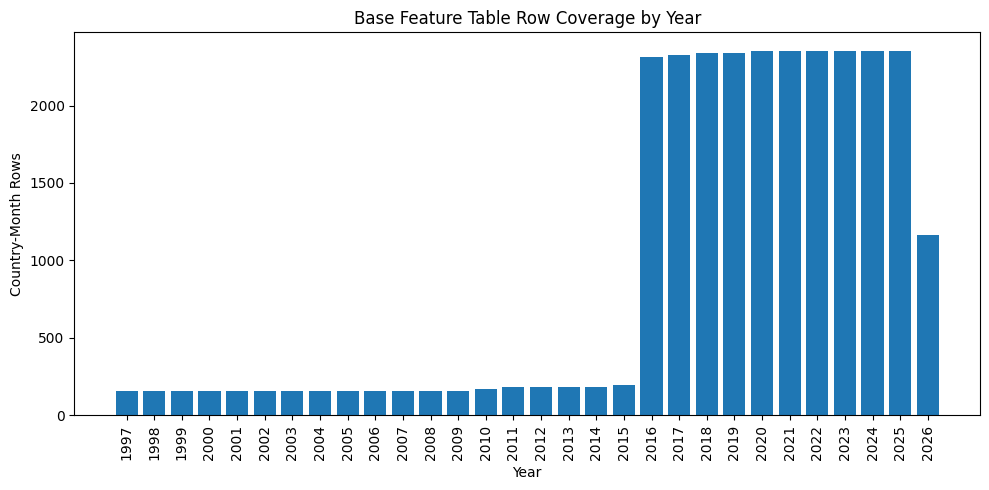

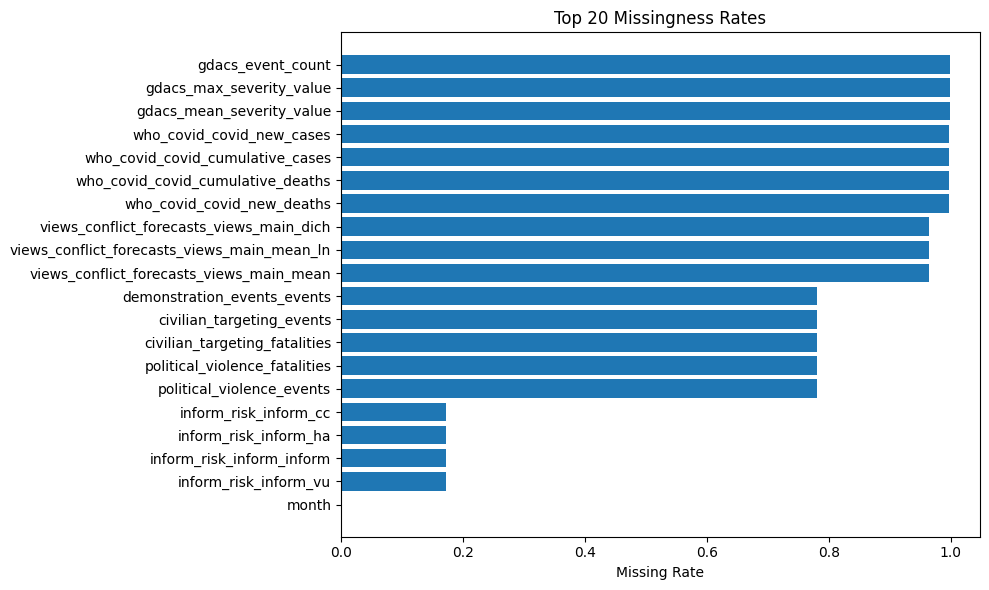

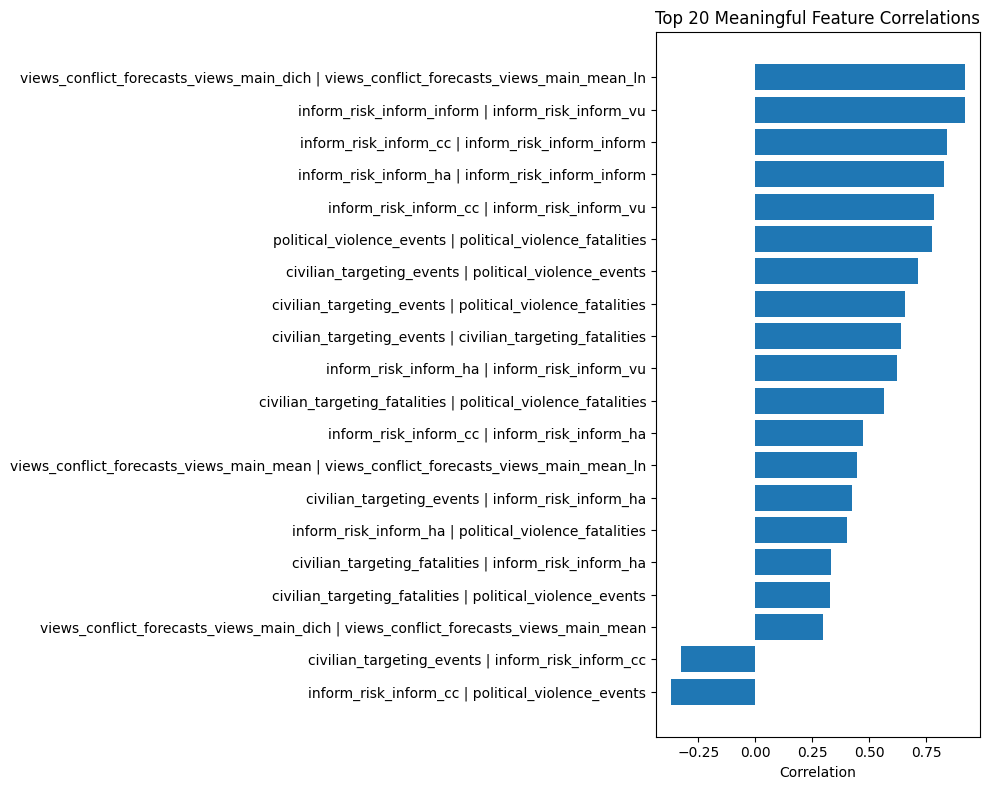

EDA visuals written to: /content/HDX-sources-and-more-API-connection/outputs/eda_visuals
[PosixPath('/content/HDX-sources-and-more-API-connection/outputs/eda_visuals/base_feature_year_coverage.png'), PosixPath('/content/HDX-sources-and-more-API-connection/outputs/eda_visuals/base_feature_top_missingness.png'), PosixPath('/content/HDX-sources-and-more-API-connection/outputs/eda_visuals/base_feature_meaningful_correlations.png')]


In [7]:
import matplotlib.pyplot as plt  # Create lightweight EDA visuals.

VISUALS_DIR = OUTPUTS_DIR / "eda_visuals"  # Set EDA visual folder.
VISUALS_DIR.mkdir(parents=True, exist_ok=True)  # Create EDA visual folder.

plt.figure(figsize=(10, 5))  # Create year coverage chart.
plt.bar(coverage["year"].astype(str), coverage["row_count"])  # Plot row count by year.
plt.xticks(rotation=90)  # Rotate year labels for readability.
plt.title("Base Feature Table Row Coverage by Year")  # Add chart title.
plt.xlabel("Year")  # Label x-axis.
plt.ylabel("Country-Month Rows")  # Label y-axis.
plt.tight_layout()  # Fit labels in figure.
plt.savefig(VISUALS_DIR / "base_feature_year_coverage.png", dpi=150)  # Save year coverage chart.
plt.show()  # Display chart in notebook.

missing_plot = missingness.head(20).sort_values("missing_rate")  # Select top missingness rows for chart.
plt.figure(figsize=(10, 6))  # Create missingness chart.
plt.barh(missing_plot["column"], missing_plot["missing_rate"])  # Plot missing rate by column.
plt.title("Top 20 Missingness Rates")  # Add chart title.
plt.xlabel("Missing Rate")  # Label x-axis.
plt.tight_layout()  # Fit labels in figure.
plt.savefig(VISUALS_DIR / "base_feature_top_missingness.png", dpi=150)  # Save missingness chart.
plt.show()  # Display chart in notebook.

corr_plot = meaningful_correlations.head(20).copy()  # Select top meaningful correlations.
corr_plot["pair"] = corr_plot["feature_1"] + " | " + corr_plot["feature_2"]  # Create readable pair label.
corr_plot = corr_plot.sort_values("correlation")  # Sort for horizontal bar display.
plt.figure(figsize=(10, 8))  # Create correlation chart.
plt.barh(corr_plot["pair"], corr_plot["correlation"])  # Plot correlation by feature pair.
plt.title("Top 20 Meaningful Feature Correlations")  # Add chart title.
plt.xlabel("Correlation")  # Label x-axis.
plt.tight_layout()  # Fit labels in figure.
plt.savefig(VISUALS_DIR / "base_feature_meaningful_correlations.png", dpi=150)  # Save correlation chart.
plt.show()  # Display chart in notebook.

print(f"EDA visuals written to: {VISUALS_DIR}")  # Show visual output folder.
print(list(VISUALS_DIR.glob("*.png")))  # Confirm visual files.


In [8]:
EDA_DIR = OUTPUTS_DIR / "eda_reports"  # Set EDA report folder.
EDA_DIR.mkdir(parents=True, exist_ok=True)  # Create EDA report folder.

missingness.to_csv(EDA_DIR / "base_feature_missingness.csv", index=False)  # Save missingness report.
coverage.to_csv(EDA_DIR / "base_feature_year_coverage.csv", index=False)  # Save year coverage report.
country_coverage.to_csv(EDA_DIR / "base_feature_country_coverage.csv", index=False)  # Save country coverage report.
numeric_summary.to_csv(EDA_DIR / "base_feature_numeric_summary.csv")  # Save numeric summary report.
meaningful_correlations.to_csv(EDA_DIR / "base_feature_meaningful_correlations.csv", index=False)  # Save filtered correlations.

print(f"EDA reports written to: {EDA_DIR}")  # Show EDA output folder.
print(list(EDA_DIR.glob("*.csv")))  # Confirm EDA files.


EDA reports written to: /content/HDX-sources-and-more-API-connection/outputs/eda_reports
[PosixPath('/content/HDX-sources-and-more-API-connection/outputs/eda_reports/base_feature_year_coverage.csv'), PosixPath('/content/HDX-sources-and-more-API-connection/outputs/eda_reports/base_feature_country_coverage.csv'), PosixPath('/content/HDX-sources-and-more-API-connection/outputs/eda_reports/base_feature_meaningful_correlations.csv'), PosixPath('/content/HDX-sources-and-more-API-connection/outputs/eda_reports/base_feature_missingness.csv'), PosixPath('/content/HDX-sources-and-more-API-connection/outputs/eda_reports/base_feature_numeric_summary.csv')]


In [9]:
from datetime import datetime  # Create timestamped backup names.
from zipfile import ZipFile, ZIP_DEFLATED  # Build compressed backup ZIP.
from google.colab import files  # Download files from Colab.

BACKUP_DIR = OUTPUTS_DIR / "local_backups"  # Set temporary backup folder.
timestamp = datetime.now().strftime("%Y%m%d_%H%M")  # Create local timestamp.
zip_path = BACKUP_DIR / f"crisis_prediction_public_pipeline_outputs_{timestamp}.zip"  # Set ZIP filename.
zip_root = f"cpo_{timestamp}"  # Keep ZIP root short for Windows path limits.

BACKUP_DIR.mkdir(parents=True, exist_ok=True)  # Create backup folder.

zip_folder_map = {
    PROJECT_ROOT / "country_month_year_outputs": "01_bronze",
    OUTPUTS_DIR / "clean_country_month_year": "02_silver",
    OUTPUTS_DIR / "model_features": "03_gold",
    OUTPUTS_DIR / "feature_reports": "04_validation",
    OUTPUTS_DIR / "eda_reports": "05_eda",
    OUTPUTS_DIR / "eda_visuals": "06_visuals",
}  # Map internal repo folders to readable ZIP folders.

with ZipFile(zip_path, "w", ZIP_DEFLATED) as zip_file:  # Create ZIP archive.
    for source_folder, zip_folder in zip_folder_map.items():  # Loop through mapped output folders.
        if source_folder.exists():  # Skip missing folders.
            for path in source_folder.rglob("*"):  # Walk folder contents.
                if path.is_file() and path != zip_path:  # Include files and avoid adding the ZIP to itself.
                    relative_path = path.relative_to(source_folder)  # Keep path inside each source folder.
                    archive_path = Path(zip_root) / zip_folder / relative_path  # Write to readable ZIP path.
                    zip_file.write(path, archive_path)  # Add file to ZIP.

print("ZIP folder mapping:")  # Introduce mapping output.
for source_folder, zip_folder in zip_folder_map.items():  # Show internal-to-ZIP mapping.
    print(f"{source_folder.relative_to(PROJECT_ROOT)} -> {zip_root}/{zip_folder}")  # Print mapping.

print(f"Created backup zip: {zip_path}")  # Show ZIP path.
files.download(str(zip_path))  # Download ZIP to local machine.




ZIP folder mapping:
country_month_year_outputs -> cpo_20260823_2050/01_bronze
outputs/clean_country_month_year -> cpo_20260823_2050/02_silver
outputs/model_features -> cpo_20260823_2050/03_gold
outputs/feature_reports -> cpo_20260823_2050/04_validation
outputs/eda_reports -> cpo_20260823_2050/05_eda
outputs/eda_visuals -> cpo_20260823_2050/06_visuals
Created backup zip: /content/HDX-sources-and-more-API-connection/outputs/local_backups/crisis_prediction_public_pipeline_outputs_20260823_2050.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>